In [1]:
print('hi')

hi


🔍 Scanning dataset...

📊 DATASET SUMMARY
----------------------------------------
Total Images: 2870
Number of Classes: 4

📁 Class Distribution:
no_tumor: 395
pituitary_tumor: 827
meningioma_tumor: 822
glioma_tumor: 826


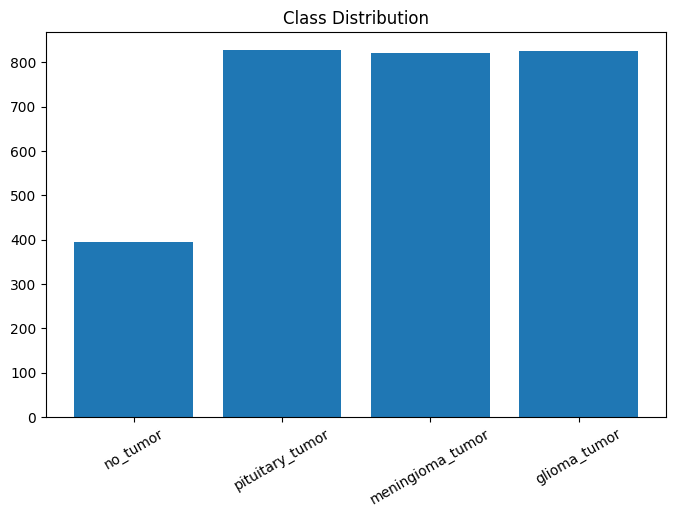


🖼️ Image Shape Info (sampled):
no_tumor: [(225, 225, 3), (504, 450, 3), (264, 210, 3)]
pituitary_tumor: [(474, 474, 3), (512, 512, 3)]
meningioma_tumor: [(225, 225, 3), (241, 230, 3), (512, 512, 3)]
glioma_tumor: [(512, 512, 3)]


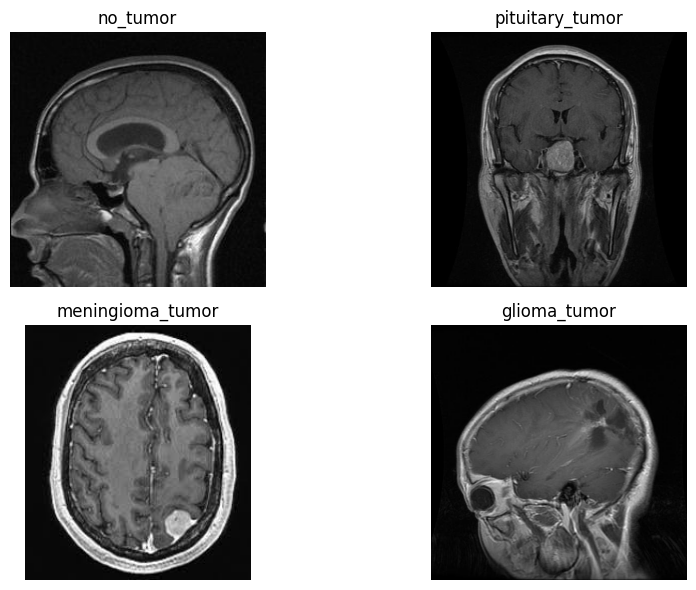

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

dataset_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"  # update this

# Store info
class_counts = {}
image_shapes = defaultdict(list)
total_images = 0

print("🔍 Scanning dataset...\n")

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        class_counts[class_name] = len(images)
        total_images += len(images)
        
        # Read few images to check size
        for img_name in images[:20]:  # sample
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                image_shapes[class_name].append(img.shape)

# 🔹 Basic Report
print("📊 DATASET SUMMARY")
print("-" * 40)
print(f"Total Images: {total_images}")
print(f"Number of Classes: {len(class_counts)}\n")

print("📁 Class Distribution:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

# 🔹 Plot Distribution
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

# 🔹 Image Shape Analysis
print("\n🖼️ Image Shape Info (sampled):")
for cls, shapes in image_shapes.items():
    unique_shapes = set(shapes)
    print(f"{cls}: {list(unique_shapes)[:3]}")

# 🔹 Show Sample Images
plt.figure(figsize=(10, 6))
for i, class_name in enumerate(class_counts.keys()):
    class_path = os.path.join(dataset_path, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [1]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze EVERYTHING
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

# Simple classifier (no heavy head)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)


2026-04-01 13:03:10.669692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775048590.897600      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775048590.964595      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775048591.541392      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775048591.541441      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775048591.541444      55 computation_placer.cc:177] computation placer alr

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


NameError: name 'train_data' is not defined

In [10]:
train_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"
test_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)


In [12]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False   # IMPORTANT for evaluation
)


Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [13]:
print("Classes:", train_data.class_indices)
print("Train batches:", len(train_data))
print("Test batches:", len(test_data))


Classes: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Train batches: 90
Test batches: 13


In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)


In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
history = model.fit(
    train_data,
    epochs=5
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1775049115.389259     131 service.cc:152] XLA service 0x78d390003750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775049115.389307     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775049115.389314     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775049118.239526     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-01 13:12:06.867730: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:12:07.011526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:12:07.369595: E external/local_xl

51/90 ━━━━━━━━━━━━━━━━━━━━ 25s 659ms/step - accuracy: 0.2770 - loss: 1.3796

2026-04-01 13:12:58.615442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:12:58.756596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:12:59.105088: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:12:59.248474: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:13:00.160054: E external/local_xla/xla/stream_

90/90 ━━━━━━━━━━━━━━━━━━━━ 109s 852ms/step - accuracy: 0.2759 - loss: 1.3726
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 449ms/step - accuracy: 0.2796 - loss: 1.3687
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 452ms/step - accuracy: 0.2818 - loss: 1.3624
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 450ms/step - accuracy: 0.2946 - loss: 1.3585
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 444ms/step - accuracy: 0.2893 - loss: 1.3585


In [17]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.5807 - loss: 1.2894

2026-04-01 13:22:34.903719: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:22:35.041017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:22:35.369733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:22:35.513202: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 13:22:36.401779: E external/local_xla/xla/stream_

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5340 - loss: 1.3095 
Test Accuracy: 0.25380709767341614


In [18]:
from sklearn.metrics import classification_report
import numpy as np

preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

print(classification_report(test_data.classes, y_pred))


13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 761ms/step
              precision    recall  f1-score   support

           0       0.25      1.00      0.40       100
           1       0.00      0.00      0.00       115
           2       0.00      0.00      0.00       105
           3       0.00      0.00      0.00        74

    accuracy                           0.25       394
   macro avg       0.06      0.25      0.10       394
weighted avg       0.06      0.25      0.10       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
history = model.fit(
    train_data,
    epochs=25
)


Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 490ms/step - accuracy: 0.2980 - loss: 1.3566
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.3008 - loss: 1.3613
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 449ms/step - accuracy: 0.2875 - loss: 1.3565
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 446ms/step - accuracy: 0.2708 - loss: 1.3607
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 447ms/step - accuracy: 0.2828 - loss: 1.3658
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 451ms/step - accuracy: 0.2972 - loss: 1.3620
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.2873 - loss: 1.3525
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.2881 - loss: 1.3530
Epoch 9/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 468ms/step - accuracy: 0.2883 - loss: 1.3606
Epoch 10/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 452ms/step - accuracy: 0.2913 - loss: 1.3578
Epoch 11/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 449ms/step - accuracy: 0.2822 - loss: 1.3592
Epoch 12/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40

KeyboardInterrupt: 

In [ ]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

# Efficient Net-B4

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.

📂 Dataset Info
Classes: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Train Samples: 2870
Test Samples: 394


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 73s 563ms/step - accuracy: 0.2848 - loss: 1.3622
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 456ms/step - accuracy: 0.2941 - loss: 1.3642
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.2773 - loss: 1.3673
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 447ms/step - accuracy: 0.2914 - loss: 1.3523
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 447ms/step - accuracy: 0.2954 - loss: 1.3620
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 450ms/step - accuracy: 0.2776 - loss: 1.3489
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 446ms/step - accuracy: 0.2822 - loss: 1.3591
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.2929 - loss: 1.3623
Epoch 9/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 449ms/step - accuracy: 0.2730 - loss: 1.3571
Epoch 10/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 445ms/step - accuracy: 0.2836 - loss: 1.3620
Epoch 11/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 445ms/step - accuracy: 0.2797 - loss: 1.3619
Epoch 12/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 40

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


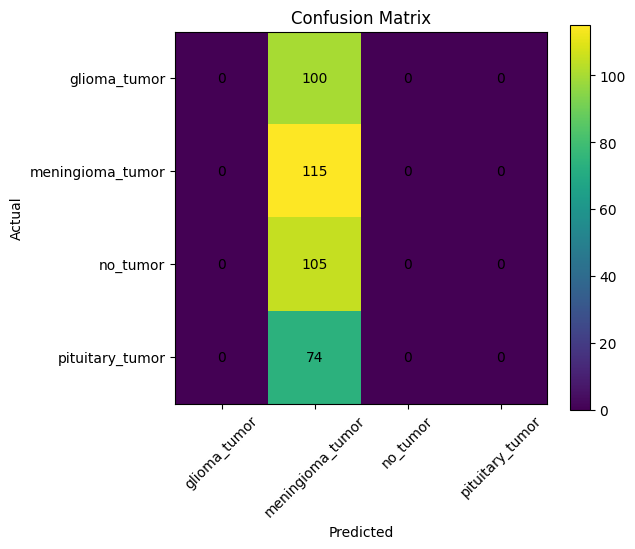

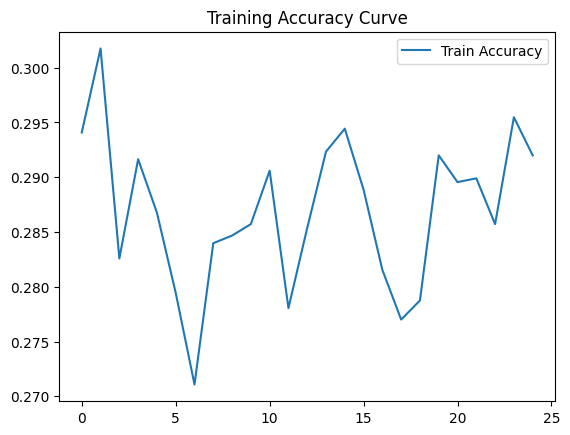


🎯 Done! Baseline model trained & evaluated.


In [20]:
# ================================
# 🧠 Brain Tumor Classification
# Full Pipeline (Single Cell)
# ================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# ================================
# 📂 Paths (EDIT THIS)
# ================================
train_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"
test_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"

# ================================
# ⚙️ Config
# ================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25  # quick baseline

# ================================
# 📊 Data Generators
# ================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# ================================
# 📥 Load Dataset
# ================================
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n📂 Dataset Info")
print("Classes:", train_data.class_indices)
print("Train Samples:", train_data.samples)
print("Test Samples:", test_data.samples)

# ================================
# 🧠 Model (EfficientNetB0)
# ================================
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# ================================
# 🔧 Compile
# ================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================================
# 🏋️ Train
# ================================
history = model.fit(
    train_data,
    epochs=EPOCHS
)

# ================================
# 📊 Evaluate
# ================================
loss, acc = model.evaluate(test_data)
print("\n✅ Test Accuracy:", round(acc, 4))

# ================================
# 📈 Predictions
# ================================
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

print("\n📊 Classification Report:\n")
print(classification_report(test_data.classes, y_pred))

# ================================
# 🔥 Confusion Matrix
# ================================
cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = list(train_data.class_indices.keys())

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 📉 Training Curve
# ================================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend()
plt.title("Training Accuracy Curve")
plt.show()

# ================================
# 💾 Save Model
# ================================
model.save("brain_tumor_baseline_model.h5")

print("\n🎯 Done! Baseline model trained & evaluated.")


In [21]:
# ================================
# 🧠 FUSION + ATTENTION MODEL
# ================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

# ================================
# 📂 PATHS
# ================================
train_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"
test_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"

IMG_SIZE = (224,224)
BATCH_SIZE = 16   # reduced for fusion (GPU safe)
EPOCHS = 10

# ================================
# 📊 DATA
# ================================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ================================
# 🧠 INPUT
# ================================
input_layer = layers.Input(shape=(224,224,3))

# ================================
# 🔥 BACKBONES
# ================================
eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_layer)
den = DenseNet121(weights='imagenet', include_top=False, input_tensor=input_layer)
res = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)

# Freeze
for model in [eff, den, res]:
    model.trainable = False

# ================================
# 📌 FEATURE EXTRACTION
# ================================
eff_feat = layers.GlobalAveragePooling2D()(eff.output)
den_feat = layers.GlobalAveragePooling2D()(den.output)
res_feat = layers.GlobalAveragePooling2D()(res.output)

# ================================
# 🔗 FUSION
# ================================
fusion = layers.Concatenate()([eff_feat, den_feat, res_feat])

# ================================
# 🧠 ATTENTION BLOCK (IMPORTANT)
# ================================
attention = layers.Dense(fusion.shape[-1], activation='softmax')(fusion)
attended = layers.Multiply()([fusion, attention])

# ================================
# 🔥 CLASSIFIER
# ================================
x = layers.BatchNormalization()(attended)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=input_layer, outputs=output)

# ================================
# ⚙️ COMPILE
# ================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# 🏋️ TRAIN
# ================================
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

# ================================
# 📊 EVALUATION
# ================================
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

print("\n📊 Classification Report:\n")
print(classification_report(test_data.classes, y_pred))

# ================================
# 📈 PLOT
# ================================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Training Curve")
plt.show()

# ================================
# 💾 SAVE MODEL
# ================================
model.save("fusion_attention_model.h5")

print("\n🚀 Fusion + Attention Model Complete!")


Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


ValueError: The name "conv1_conv" is used 2 times in the model. All operation names should be unique.

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_4[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_4[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_4[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4352)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4352)      │ 18,944,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 4352)      │          0 │ concatenate_1[0]… │
│ (Multiply)          │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4352)      │     17,408 │ multiply_1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │  1,114,368 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,751,847 (208.86 MB)

 Trainable params: 20,068,356 (76.55 MB)

...

 20/359 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - accuracy: 0.3049 - loss: 1.3838

2026-04-01 14:02:47.671042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:02:47.806351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:02:48.143223: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:02:48.286718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:02:49.192041: E external/local_xla/xla/stream_

359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.5501 - loss: 1.1087

2026-04-01 14:04:34.249094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:04:34.383819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:04:34.711303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:04:34.854581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 14:04:35.731458: E external/local_xla/xla/stream_

359/359 ━━━━━━━━━━━━━━━━━━━━ 218s 398ms/step - accuracy: 0.5504 - loss: 1.1080 - val_accuracy: 0.3706 - val_loss: 1.3059
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 135ms/step - accuracy: 0.7839 - loss: 0.5666 - val_accuracy: 0.5305 - val_loss: 1.3424
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 134ms/step - accuracy: 0.8388 - loss: 0.4627 - val_accuracy: 0.5787 - val_loss: 1.5273
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 49s 135ms/step - accuracy: 0.8451 - loss: 0.4197 - val_accuracy: 0.5761 - val_loss: 1.4822
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 49s 136ms/step - accuracy: 0.8495 - loss: 0.4154 - val_accuracy: 0.6396 - val_loss: 1.3557
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 135ms/step - accuracy: 0.8433 - loss: 0.3911 - val_accuracy: 0.6117 - val_loss: 1.4054
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 49s 135ms/step - accuracy: 0.8798 - loss: 0.3343 - val_accuracy: 0.5736 - val_loss: 1.3597
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 133ms/step - accuracy: 0.8857 - loss: 0.3066 - va

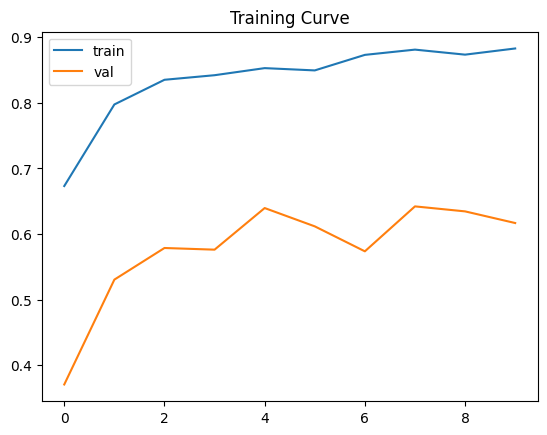


🚀 Model trained successfully!


In [23]:
# ================================
# 🧠 FIXED FUSION + ATTENTION MODEL
# ================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

# ================================
# 📂 PATHS
# ================================
train_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"
test_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"

IMG_SIZE = (224,224)
BATCH_SIZE = 8   # safer for fusion
EPOCHS = 10

# ================================
# 📊 DATA
# ================================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ================================
# 🧠 INPUT
# ================================
input_layer = layers.Input(shape=(224,224,3))

# ================================
# 🔥 BACKBONES (NO shared input!)
# ================================
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
den_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
res_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for model_base in [eff_base, den_base, res_base]:
    model_base.trainable = False

# Pass SAME input through each model
eff_feat = eff_base(input_layer)
den_feat = den_base(input_layer)
res_feat = res_base(input_layer)

# ================================
# 📌 FEATURE EXTRACTION
# ================================
eff_feat = layers.GlobalAveragePooling2D()(eff_feat)
den_feat = layers.GlobalAveragePooling2D()(den_feat)
res_feat = layers.GlobalAveragePooling2D()(res_feat)

# ================================
# 🔗 FUSION
# ================================
fusion = layers.Concatenate()([eff_feat, den_feat, res_feat])

# ================================
# 🧠 ATTENTION
# ================================
attention = layers.Dense(fusion.shape[-1], activation='softmax')(fusion)
attended = layers.Multiply()([fusion, attention])

# ================================
# 🔥 CLASSIFIER
# ================================
x = layers.BatchNormalization()(attended)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=input_layer, outputs=output)

# ================================
# ⚙️ COMPILE
# ================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# 🏋️ TRAIN
# ================================
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

# ================================
# 📊 EVALUATION
# ================================
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

print("\n📊 Classification Report:\n")
print(classification_report(test_data.classes, y_pred))

# ================================
# 📈 PLOT
# ================================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Training Curve")
plt.show()

# ================================
# 💾 SAVE
# ================================
model.save("fusion_attention_model_fixed.h5")

print("\n🚀 Model trained successfully!")


Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_8[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_8[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_8[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 4352)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 4352)      │ 18,944,256 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 4352)      │          0 │ concatenate_2[0]… │
│ (Multiply)          │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4352)      │     17,408 │ multiply_2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │  1,114,368 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 54,751,847 (208.86 MB)

 Trainable params: 20,068,356 (76.55 MB)

 Non-trainable params: 34,683,491 (132.31 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.5045 - loss: 1.2881 - val_accuracy: 0.2919 - val_loss: 1.4439
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 511ms/step - accuracy: 0.7837 - loss: 0.6295 - val_accuracy: 0.2995 - val_loss: 1.3798
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 498ms/step - accuracy: 0.8210 - loss: 0.4702 - val_accuracy: 0.3020 - val_loss: 1.3688
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 510ms/step - accuracy: 0.8518 - loss: 0.4060 - val_accuracy: 0.4010 - val_loss: 1.3061
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 503ms/step - accuracy: 0.8483 - loss: 0.4012 - val_accuracy: 0.4949 - val_loss: 1.2214
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 503ms/step - accuracy: 0.8769 - loss: 0.3406 - val_accuracy: 0.6066 - val_loss: 1.1041
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 506ms/step - accuracy: 0.8758 - loss: 0.3366 - val_accuracy: 0.6244 - val_loss: 1.2060
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 509ms/step - accuracy: 0.8909 - loss: 0.2965 - val_accura

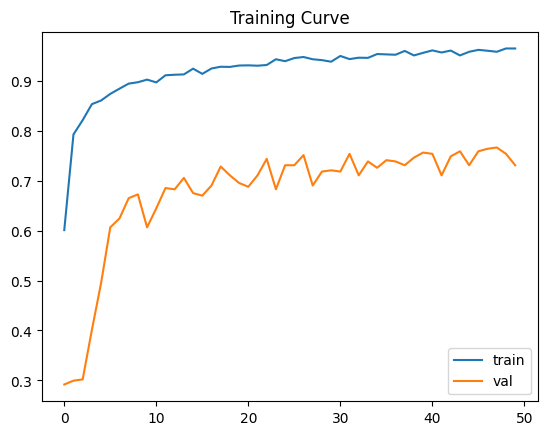


🚀 Model trained successfully!


In [24]:
# ================================
# 🧠 FIXED FUSION + ATTENTION MODEL
# ================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, ResNet50
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

# ================================
# 📂 PATHS
# ================================
train_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"
test_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"

IMG_SIZE = (224,224)
BATCH_SIZE = 32   # safer for fusion
EPOCHS = 50

# ================================
# 📊 DATA
# ================================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ================================
# 🧠 INPUT
# ================================
input_layer = layers.Input(shape=(224,224,3))

# ================================
# 🔥 BACKBONES (NO shared input!)
# ================================
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
den_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
res_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze
for model_base in [eff_base, den_base, res_base]:
    model_base.trainable = False

# Pass SAME input through each model
eff_feat = eff_base(input_layer)
den_feat = den_base(input_layer)
res_feat = res_base(input_layer)

# ================================
# 📌 FEATURE EXTRACTION
# ================================
eff_feat = layers.GlobalAveragePooling2D()(eff_feat)
den_feat = layers.GlobalAveragePooling2D()(den_feat)
res_feat = layers.GlobalAveragePooling2D()(res_feat)

# ================================
# 🔗 FUSION
# ================================
fusion = layers.Concatenate()([eff_feat, den_feat, res_feat])

# ================================
# 🧠 ATTENTION
# ================================
attention = layers.Dense(fusion.shape[-1], activation='softmax')(fusion)
attended = layers.Multiply()([fusion, attention])

# ================================
# 🔥 CLASSIFIER
# ================================
x = layers.BatchNormalization()(attended)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=input_layer, outputs=output)

# ================================
# ⚙️ COMPILE
# ================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ================================
# 🏋️ TRAIN
# ================================
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

# ================================
# 📊 EVALUATION
# ================================
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

print("\n📊 Classification Report:\n")
print(classification_report(test_data.classes, y_pred))

# ================================
# 📈 PLOT
# ================================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Training Curve")
plt.show()

# ================================
# 💾 SAVE
# ================================
model.save("fusion_attention_model_fixed.h5")

print("\n🚀 Model trained successfully!")
